### Structured Output

Models can be requested to provide their response in a format matching a given schema. This is useful for ensuring the output can be ensuring the output can be easily parsed and used in subsequent processing. Langchain supports multiple schema types and methods for enforcing structured output

In [1]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]
model = init_chat_model("groq:llama-3.3-70b-versatile")
model.profile

{'name': 'Llama 3.3 70B Versatile',
 'release_date': '2024-12-06',
 'last_updated': '2024-12-06',
 'open_weights': True,
 'max_input_tokens': 131072,
 'max_output_tokens': 32768,
 'text_inputs': True,
 'image_inputs': False,
 'audio_inputs': False,
 'video_inputs': False,
 'text_outputs': True,
 'image_outputs': False,
 'audio_outputs': False,
 'video_outputs': False,
 'reasoning_output': False,
 'tool_calling': True,
 'attachment': False,
 'temperature': True}

#### Pydantic

Pydantic models provide the richest feature set with field validation, descriptions, and nested structures.

In [2]:
from pydantic import BaseModel, Field

class Movie(BaseModel):
    title: str = Field(description = "The title of the movie")
    year: int = Field(description = "This year the movie was released")
    director: str = Field(description = "The director of the movie")
    rating: float = Field(description = "The movies rating out of 10")

In [ ]:
structuredModel = model.with_structured_output(Movie)
rawStructuredModel = model.with_structured_output(Movie, include_raw=True)

print("StructuredModel:\n", structuredModel)
print("RawStructuredModel:\n", rawStructuredModel)

StructuredModel:
 first=_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BE318706E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BE31871400>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'Movie', 'descript

In [5]:
response = structuredModel.invoke("Provide me details about the movie Inception")
rawResponse = rawStructuredModel.invoke("Provide me details about the movie Inception")
print("Response:", response)
print("Raw Response:", rawResponse)

Response: title='Inception' year=2010 director='Christopher Nolan' rating=8.5
Raw Response: {'raw': AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'z281vn14t', 'function': {'arguments': '{"director":"Christopher Nolan","rating":8.5,"title":"Inception","year":2010}', 'name': 'Movie'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 280, 'total_tokens': 312, 'completion_time': 0.056946697, 'completion_tokens_details': None, 'prompt_time': 0.037084871, 'prompt_tokens_details': None, 'queue_time': 0.049055034, 'total_time': 0.094031568}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1039-7c83-7623-b0d8-6ca136d798a5-0', tool_calls=[{'name': 'Movie', 'args': {'director': 'Christopher Nolan', 'rating': 8.5, 'title': 'Inception', 'year': 2010}, 'id': 'z281vn14t', 'type': 'to

##### Nested Structure

In [ ]:
from pydantic import BaseModel, Field

class Actor(BaseModel):
    name: str
    role: str

class MovieDetails(BaseModel):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: float | None = Field(None, description="Budget in millions USD")

structuredModel = model.with_structured_output(MovieDetails)

response = structuredModel.invoke("Provide details about the movie Inception")
response

MovieDetails(title='Inception', year=2010, cast=[Actor(name='Leonardo DiCaprio', role='Cobb'), Actor(name='Joseph Gordon-Levitt', role='Arthur')], genres=['Action', 'Sci-Fi'], budget=160.0)

#### Typed Dict

TypedDict provides a simpler alternative using Python's built in typing, ideal when we do not need **runtime validation**

In [2]:
from typing_extensions import TypedDict, Annotated, NotRequired

class MovieDict(TypedDict):
    '''A movie with details'''
    title: Annotated[str, ..., "The title of the movie"]
    year: Annotated[int, ..., "The year the movie was released"]
    director: Annotated[str, ..., "The director of the movie"]
    rating: Annotated[float, ..., "The movie's rating out of 10"]

In [ ]:
typedDictModel = model.with_structured_output(MovieDict)
response = typedDictModel.invoke("Provide me details about the movie Inception")
response

{'director': 'Christopher Nolan',
 'rating': 8.5,
 'title': 'Inception',
 'year': 2010}

In [ ]:
class Actor(TypedDict):
    name: str
    role: str

class MovieDetails(TypedDict):
    title: str
    year: int
    cast: list[Actor]
    genres: list[str]
    budget: NotRequired[float | None]

typedDictModel = model.with_structured_output(MovieDetails)
response = typedDictModel.invoke("Provide me details about the movie Inception")
response

{'budget': 160000000,
 'cast': [{'name': 'Leonardo DiCaprio', 'role': 'Cobb'},
  {'name': 'Joseph Gordon-Levitt', 'role': 'Arthur'}],
 'genres': ['Action', 'Sci-Fi'],
 'title': 'Inception',
 'year': 2010}

#### Data Classes

A data class is a class typically containing mainly data, although they aren't really any restrictions. You create it using the **@dataclass** decorator

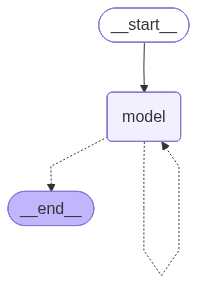

In [3]:
from pydantic import BaseModel, Field
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model 

class ContactInfo(BaseModel):
    '''Contact information for a person'''
    name: str = Field(description = "The name of the person")
    email: str = Field(description = "The email address of the person")
    phone: str = Field(description = "The phone number of the person")

model = init_chat_model("groq:llama-3.3-70b-versatile")
agent = create_agent(model=model, tools=[], response_format=ContactInfo)

agent

In [5]:
result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

print(result)
result['structured_response']

{'messages': [HumanMessage(content='Extract contact info from: John Doe, john@example.com, (555) 123-4567', additional_kwargs={}, response_metadata={}, id='0403f43e-e1a1-4a51-a8d4-480811483263'), AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'x0jfdcj6k', 'function': {'arguments': '{"email":"john@example.com","name":"John Doe","phone":"(555) 123-4567"}', 'name': 'ContactInfo'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 288, 'total_tokens': 321, 'completion_time': 0.060694888, 'completion_tokens_details': None, 'prompt_time': 0.014421119, 'prompt_tokens_details': None, 'queue_time': 0.051097421, 'total_time': 0.075116007}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f105d-c625-7600-9d01-5e791636c922-0', tool_calls=[{'name': 'ContactInfo', 'args': {'email': 'joh

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')

In [7]:
## Typedict
from typing_extensions import TypedDict
from langchain.agents import create_agent


class ContactInfo(TypedDict):
    """Contact information for a person."""
    name: str
    email: str
    phone: str

agent = create_agent(
    model=model,
    response_format=ContactInfo
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]

{'name': 'John Doe', 'email': 'john@example.com', 'phone': '(555) 123-4567'}

In [8]:
## Dataclass

from dataclasses import dataclass
from langchain.agents import create_agent

@dataclass
class ContactInfo:
    """Contact information for a person."""
    name: str
    email: str
    phone: str


agent = create_agent(
    model=model,
    response_format=ContactInfo
)

result = agent.invoke({
    "messages": [{"role": "user", "content": "Extract contact info from: John Doe, john@example.com, (555) 123-4567"}]
})

result["structured_response"]

ContactInfo(name='John Doe', email='john@example.com', phone='(555) 123-4567')